## Module 1: Phân tích Tỷ lệ Tử vong (Mortality Analysis)

Trong Module 1 này, mục tiêu là:
1. Tính toán **Xác suất sống trong 1 năm** ($p_x$) và **Xác suất sống tích lũy** (${}_t p_x$).
2. Trực quan hóa **Đường cong tử vong (Mortality Curve)** và **Đường cong sinh tồn (Survival Curve)** để làm cơ sở cho việc định phí và tính dòng tiền ở các phần sau.

In [5]:
import pandas as pd

# Đọc dữ liệu 
mortality = pd.read_csv("../data/mortality_table.csv")

# In ra 5 dòng đầu tiên để kiểm tra
mortality.head()


,age,qx
0,30,0.00095
1,31,0.00100
2,32,0.00105
3,33,0.00110
4,34,0.00115



**Công thức:**
Xác suất một người ở độ tuổi $x$ sống sót qua $t$ năm tiếp theo (${}_t p_x$) được tính bằng tích của các xác suất sống từng năm ($p_x$):
$${}_t p_x = p_x \times p_{x+1} \times \dots \times p_{x+t-1}$$

In [6]:
# 1. Tính Xác suất sống trong 1 năm (px)
# Bằng 100% (hay 1) trừ đi xác suất tử vong (qx)
mortality['px'] = 1 - mortality['qx']

# 2. Tính Xác suất sống tích lũy từ năm đầu tiên (tpx)
# Hàm cumprod() sẽ nhân dồn các xác suất sống lại với nhau qua từng năm
mortality['cumulative_survival'] = mortality['px'].cumprod()

# 3. In ra 5 dòng đầu tiên để xem thành quả
mortality.head()

,age,qx,px,cumulative_survival
0,30,0.00095,0.99905,0.999050
1,31,0.00100,0.99900,0.998051
2,32,0.00105,0.99895,0.997003
3,33,0.00110,0.99890,0.995906
4,34,0.00115,0.99885,0.994761


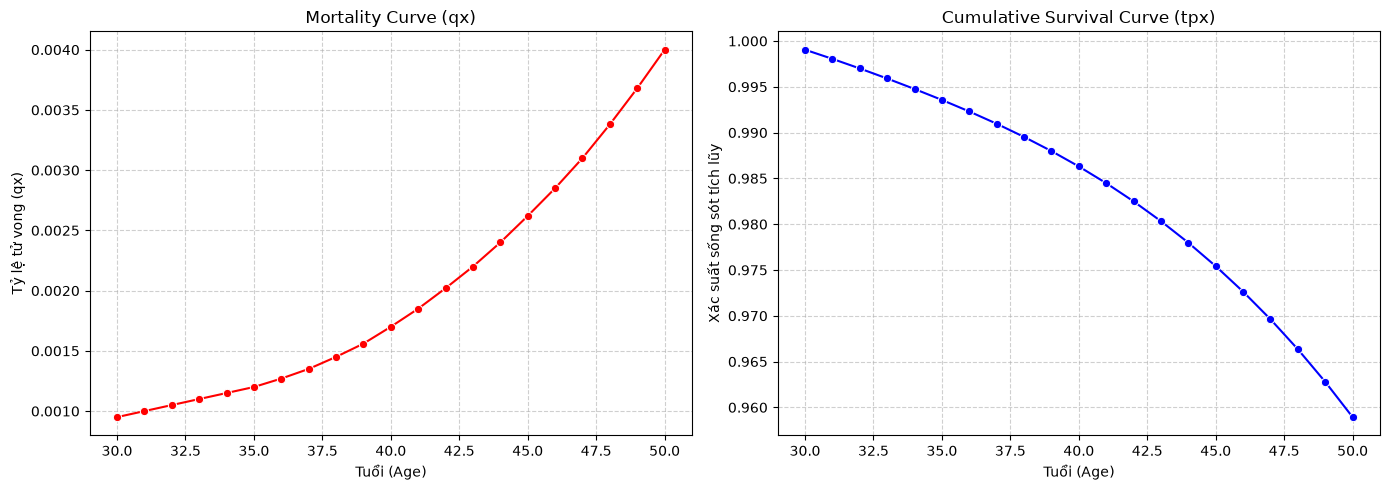

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Đường cong tử vong (Mortality Curve) 
sns.lineplot(data=mortality, x='age', y='qx', ax=axes[0], color='red', marker='o')
axes[0].set_title('Mortality Curve (qx)')
axes[0].set_xlabel('Tuổi (Age)')
axes[0].set_ylabel('Tỷ lệ tử vong (qx)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Đường cong sinh tồn (Survival Curve) 
sns.lineplot(data=mortality, x='age', y='cumulative_survival', ax=axes[1], color='blue', marker='o')
axes[1].set_title('Cumulative Survival Curve (tpx)')
axes[1].set_xlabel('Tuổi (Age)')
axes[1].set_ylabel('Xác suất sống sót tích lũy')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../outputs/mortality_survival_curves.png')
plt.show()

### Nhận xét Biểu đồ (Data Interpretation)

Dựa vào kết quả trực quan hóa, ta có thể rút ra các kết luận sau:

*   **Mortality Curve (Đường cong tử vong):** Đường màu đỏ có xu hướng cong vút lên trên. Điều này phản ánh thực tế sinh học: khi độ tuổi $x$ càng cao (từ 30 đến 50), rủi ro tử vong trong năm đó ($q_x$) càng tăng lên.
*   **Survival Curve (Đường cong sinh tồn):** Đường màu xanh lao dốc xuống dưới. Nó cho thấy xác suất một khách hàng 30 tuổi có thể sống sót liên tục đến năm 40, 45, 50 tuổi sẽ ngày càng giảm đi theo thời gian.